## Påverkan av naturlig grundvattenvildning
*Del 1: Kalibrering med klimatdata*

Denna notebook kalibrerar en grundvattenmodell med klimatdata för brunn HK4117U.

Steg:
1. Importera bibliotek
2. Ladda och förbered data
3. Bygg och kalibrera klimatmodell
4. Visa kalibreringsresultat
5. Spara modell för nästa notebook

### 0. Importera bibliotek

In [1]:
import os
import pandas as pd
import pastas as ps
from sklearn.metrics import r2_score

### 1. Ladda och förbered data

In [3]:
WELL_NAME = "17U"
data_mapp = "../data"

# Load well data 
Ho = (
    pd.read_csv(
        os.path.join(data_mapp, "gw_tunnel_gbg.csv"),
        sep=";",
        parse_dates=["Date"],
        index_col="Date"
    )["Value"]
    .sort_index(ascending=True)
    .loc["2017-07-01":]
)

In [4]:

precipitation = (
    pd.read_csv(os.path.join(data_mapp, "P_gbg_tunnel.csv"), sep=";")
    .rename(columns={
        "Nederbördsmängd": "Precipitation",
        "Representativt dygn": "rep_day",
        "Tid (UTC)": "time_utc",
    })
    .assign(
        Date=lambda d: pd.to_datetime(
            d["rep_day"].astype(str) + " " + d["time_utc"].astype(str),
            errors="coerce",
        )
    )
    .loc[lambda d: d["Date"] > pd.Timestamp("2012-12-31"), ["Date", "Precipitation"]]
    .set_index("Date")["Precipitation"]
)

rain = precipitation.groupby(pd.Grouper(freq="D")).mean().round(1)

evap = (
    pd.read_csv(os.path.join(data_mapp, "ET_gbg_tunnel.csv"), sep=";")
    .assign(Date=lambda d: pd.to_datetime(d["Date"], errors="coerce"))
    .set_index("Date")["ETo_FAO_mm"]
)

recharge = rain.sub(evap, fill_value=0).rename("Recharge")

print(f"Brunn: {WELL_NAME}")
print(f"Observationer: {Ho.dropna().shape[0]}")
print(f"Nederbördspunkter: {rain.dropna().shape[0]}")
print(f"Avdunstningspunkter: {evap.dropna().shape[0]}")

Brunn: 17U
Observationer: 889
Nederbördspunkter: 3004
Avdunstningspunkter: 2909


### 2. Bygg och kalibrera klimatmodell

The Time Series 'Value' has nan-values. Pastas will use the fill_nan settings to fill up the nan-values.
The Time Series 'Precipitation' has nan-values. Pastas will use the fill_nan settings to fill up the nan-values.
The Time Series 'ETo_FAO_mm' has nan-values. Pastas will use the fill_nan settings to fill up the nan-values.


<Axes: xlabel='Date', ylabel='Head'>

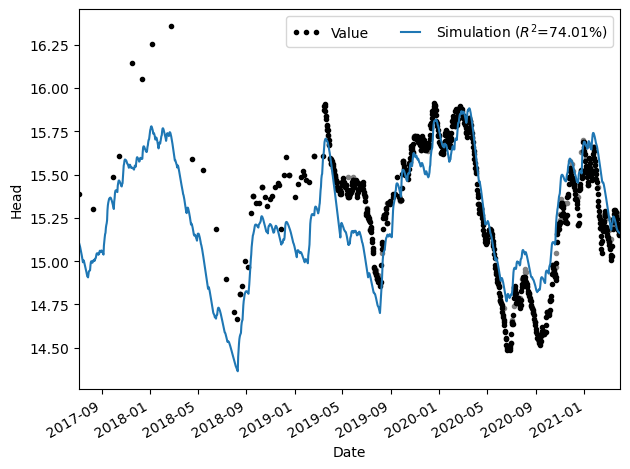

In [5]:
tmin = "2017-07-01"
tmax = "2021-04-01"

ml_1 = ps.Model(Ho, name=f"{WELL_NAME}_m1")

sm_recharge = ps.RechargeModel(
    rain,
    evap,
    rfunc=ps.Gamma(),
    recharge=ps.rch.Linear(),
    name="recharge",
)
ml_1.add_stressmodel(sm_recharge)

ml_1.solve(
    report=False,
    solver=ps.LmfitSolve(),
    tmin=tmin,
    tmax=tmax,
)

ml_1.plot()

### 3. Visa kalibreringsresultat

[<Axes: xlabel='Date', ylabel='Head'>,
 <Axes: xlabel='Date'>,
 <Axes: title={'right': "Stresses: ['Precipitation', 'ETo_FAO_mm']"}, ylabel='Rise'>,
 <Axes: title={'center': 'Step response'}, xlabel='Time [days]'>,
 <Axes: title={'left': 'Model Parameters ($n_c$=5)'}>]

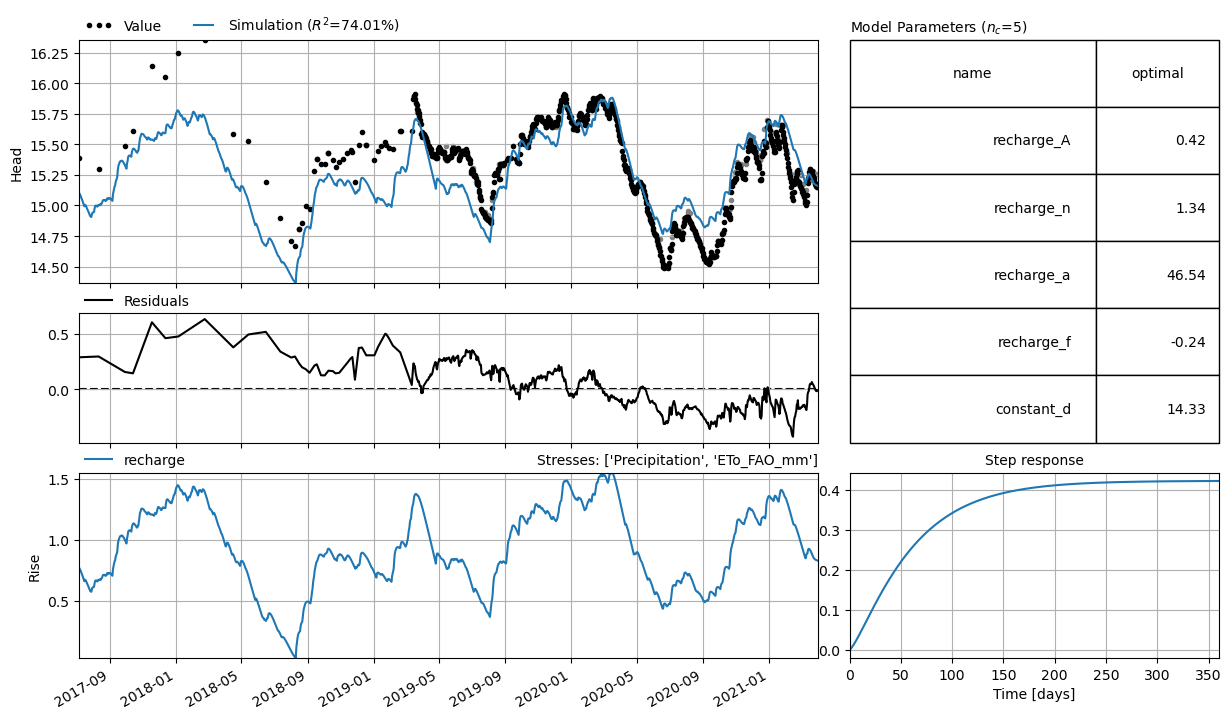

In [7]:
ml_1.plots.results(figsize=(12, 7))

Residualerna visar att modellen förklarar inte hela grundvattennivåtidsserien

### 4. Spara modell för nästa notebook

In [8]:
model_path = "../data/obj_17U_m1.pas"
ml_1.to_file(model_path)
print(f"Modell sparad: {model_path}")

Modell sparad: ../data/obj_17U_m1.pas
